# 05 — Phase 2 v0: Feature Pipeline

Builds the first ML-ready feature snapshot for delay prediction. Loads the
GTFS-RT `trip_updates` archive and the static GTFS archive from S3, joins them
on `(trip_id, stop_id)` to attach the schedule that was actually in effect on
each realtime date, engineers time/mode features, and writes the result to a
new S3 prefix (`ml_features/v0_feature_snapshot/`).

This is a pipeline-building step — **no model training happens in this
notebook**. Raw archives under `gtfs_realtime/` and `gtfs_static/` are only
ever read, never written to.

In [1]:
# Cell 0 — Environment setup: load .env, configure S3 access
import os
import subprocess
import sys
from pathlib import Path

try:
    from dotenv import load_dotenv, find_dotenv
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'python-dotenv', '-q'], check=True)
    from dotenv import load_dotenv, find_dotenv

try:
    import s3fs
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 's3fs', '-q'], check=True)
    import s3fs

_dotenv_path = find_dotenv(usecwd=True)
if _dotenv_path:
    load_dotenv(_dotenv_path, override=False)
    print(f'Loaded .env from: {_dotenv_path}')
else:
    print('No .env file found — using defaults.')

S3_BUCKET = os.environ.get('AWS_S3_BUCKET', '')
AWS_REGION = os.environ.get('AWS_REGION', 'ap-southeast-2')
REPO_DIR   = os.environ.get('TRANSIT_AI_REPO_DIR', str(Path.cwd().parent))

if not S3_BUCKET:
    raise EnvironmentError('AWS_S3_BUCKET is not set. Check your .env file.')

assert S3_BUCKET == 'seq-transit-ai-data-ps', (
    f'Expected bucket seq-transit-ai-data-ps, got {S3_BUCKET!r}'
)

fs = s3fs.S3FileSystem()

print(f'S3_BUCKET: {S3_BUCKET}')
print(f'AWS_REGION: {AWS_REGION}')
print(f'REPO_DIR: {REPO_DIR}')

Loaded .env from: /Users/proteeksanyal/Desktop/Learning/Transit-AI/.env
S3_BUCKET: seq-transit-ai-data-ps
AWS_REGION: ap-southeast-2
REPO_DIR: /Users/proteeksanyal/Desktop/Learning/Transit-AI


## Step 2 — GTFS-RT `trip_updates` coverage

List every `YYYY-MM-DD` folder under `gtfs_realtime/trip_updates/` and count
snapshot files per day, so we know actual coverage before anything downstream
runs.

In [2]:
# Cell 1 — List available trip_updates dates and snapshot file counts
import re

# Test-mode switch: restrict loading to a single date for a fast dry run.
# Set DATE_LIMIT = None to opt in to the full available date range.
DATE_LIMIT = None

RT_PREFIX = f'{S3_BUCKET}/gtfs_realtime/trip_updates'
date_pattern = re.compile(r'^\d{4}-\d{2}-\d{2}$')

try:
    rt_entries = fs.ls(RT_PREFIX)
except Exception as e:
    raise FileNotFoundError(f'Cannot list s3://{RT_PREFIX}: {e}')

all_rt_dates = sorted([
    e.rstrip('/').split('/')[-1] for e in rt_entries
    if date_pattern.match(e.rstrip('/').split('/')[-1])
])

if not all_rt_dates:
    raise FileNotFoundError(
        f'No YYYY-MM-DD subfolders found under s3://{RT_PREFIX}.\n'
        'Run scripts/archive_gtfsrt.py first to start collecting trip_updates.'
    )

if DATE_LIMIT is not None:
    rt_dates = [d for d in all_rt_dates if d == DATE_LIMIT]
    if not rt_dates:
        raise ValueError(
            f'DATE_LIMIT={DATE_LIMIT!r} not found among available dates: {all_rt_dates}'
        )
    print(f'[TEST MODE] DATE_LIMIT={DATE_LIMIT!r} — restricting to 1 of {len(all_rt_dates)} available date(s)\n')
else:
    rt_dates = all_rt_dates
    print(f'DATE_LIMIT=None — loading full available range ({len(all_rt_dates)} date(s))\n')

rt_file_counts = {}
for d in rt_dates:
    files = [f for f in fs.ls(f'{RT_PREFIX}/{d}') if f.endswith('.json')]
    rt_file_counts[d] = len(files)

print(f'trip_updates coverage in scope: {rt_dates[0]} → {rt_dates[-1]}  ({len(rt_dates)} day(s))\n')
for d in rt_dates:
    print(f'  {d}: {rt_file_counts[d]:>4} snapshot files')

print(f'\nTotal snapshot files in scope: {sum(rt_file_counts.values()):,}')

DATE_LIMIT=None — loading full available range (18 date(s))



trip_updates coverage in scope: 2026-06-28 → 2026-07-15  (18 day(s))

  2026-06-28:  100 snapshot files
  2026-06-29:   63 snapshot files
  2026-06-30:   50 snapshot files
  2026-07-01:  111 snapshot files
  2026-07-02:   61 snapshot files
  2026-07-03:   82 snapshot files
  2026-07-04:  106 snapshot files
  2026-07-05:   71 snapshot files
  2026-07-06:  163 snapshot files
  2026-07-07:   65 snapshot files
  2026-07-08:   67 snapshot files
  2026-07-09:   32 snapshot files
  2026-07-10:   22 snapshot files
  2026-07-11:    8 snapshot files
  2026-07-12:   44 snapshot files
  2026-07-13:   82 snapshot files
  2026-07-14:   63 snapshot files
  2026-07-15:   28 snapshot files

Total snapshot files in scope: 1,218


## Step 3 — Load static GTFS from S3

Load `trips.txt`, `stop_times.txt`, `routes.txt`, `calendar.txt` for a single,
explicitly chosen static snapshot — `STATIC_SNAPSHOT_DATE`, defined below.

In [3]:
# Cell 2 — Load static GTFS txt files for the selected snapshot
import pandas as pd

STATIC_PREFIX = f'{S3_BUCKET}/gtfs_static'

try:
    static_entries = fs.ls(STATIC_PREFIX)
except Exception as e:
    raise FileNotFoundError(f'Cannot list s3://{STATIC_PREFIX}: {e}')

static_dates = sorted([
    e.rstrip('/').split('/')[-1] for e in static_entries
    if date_pattern.match(e.rstrip('/').split('/')[-1])
])

if not static_dates:
    raise FileNotFoundError(
        f'No YYYY-MM-DD subfolders found under s3://{STATIC_PREFIX}.\n'
        'Run scripts/archive_gtfsrt.py (static download) first.'
    )

# Explicit, deliberate choice of which static schedule to join against.
# Default: auto-detect the most recent available snapshot. Override with any
# value from `static_dates` printed below to pin a specific schedule version.
STATIC_SNAPSHOT_DATE = max(static_dates)

print(f'Static GTFS snapshots available: {static_dates}')
print(f'>>> Using static snapshot: {STATIC_SNAPSHOT_DATE} <<<\n')

def load_static_txt(snapshot_date, name):
    s3_path = f's3://{STATIC_PREFIX}/{snapshot_date}/{name}'
    try:
        return pd.read_csv(s3_path, dtype=str)
    except FileNotFoundError:
        print(f'  {name} not found for {snapshot_date} — skipping')
        return None

trips      = load_static_txt(STATIC_SNAPSHOT_DATE, 'trips.txt')
stop_times = load_static_txt(STATIC_SNAPSHOT_DATE, 'stop_times.txt')
routes     = load_static_txt(STATIC_SNAPSHOT_DATE, 'routes.txt')
calendar   = load_static_txt(STATIC_SNAPSHOT_DATE, 'calendar.txt')

print(
    f'  trips={len(trips):,}, stop_times={len(stop_times):,}, '
    f'routes={len(routes):,}, calendar={len(calendar):,}'
)

Static GTFS snapshots available: ['2026-06-28', '2026-07-01', '2026-07-08']
>>> Using static snapshot: 2026-07-08 <<<



  trips=131,646, stop_times=3,394,453, routes=1,418, calendar=181


## Incremental runs: a lookback window instead of a full reprocess, deliberately

Earlier versions of this notebook reprocessed the entire GTFS-RT archive on
every run. As the archive grows day over day, that gets increasingly
expensive — every run re-fetches, re-joins, and re-writes weeks of data that
haven't changed since the last run. From this version on, only a
**lookback window** of `LOOKBACK_DAYS` trailing days (default `3`) plus any
date the previous manifest doesn't already cover (`touch_dates`, computed
below) gets recomputed each run; everything else is copied forward
unchanged, S3-to-S3, from the previous run's output (`carry_forward_dates`).

`LOOKBACK_DAYS=3` is a deliberate choice, not an arbitrary one: GTFS-RT
snapshot files for a given day can keep arriving for a day or two after
that day ends (the archiver isn't guaranteed to have collected every
snapshot by midnight), so a too-short lookback risks permanently locking in
a day's data before it's fully collected. A 3-day trailing window catches
that late-arriving/incomplete data without redoing the whole history.

Today's own date is excluded from `touch_dates` by default —
`INCLUDE_TODAY_PARTIAL` must be explicitly set to `True` to process it —
because today's snapshot collection is still in progress while this
notebook runs. Including it by default would mean silently writing a
partition that's known to be incomplete; `INCLUDE_TODAY_PARTIAL` makes that
an explicit opt-in instead, and any such partial day is tracked separately
in the manifest's `partial_dates` rather than mixed in with genuinely
completed recomputes.

## Step 3c — Incremental run config (stage 1: read previous-run state only)

Stage 1 of 5 in converting this notebook from a full reprocess to an
incremental run. This introduces the config knobs (`LOOKBACK_DAYS`,
`INCLUDE_TODAY_PARTIAL`) and a lookup of the previous run's
`_latest.json` manifest that later stages will use to only fetch/process
new data. **This stage is read-only** — it does not change which dates get
fetched, joined, or written below; that logic is untouched until a later
stage.

In [ ]:
# Cell 2c — Incremental-run config (stage 1 — not yet wired into the fetch/join/write logic below)
LOOKBACK_DAYS = 3              # trailing days to re-check for late-arriving records once incremental fetch is wired up (stage 2+)
INCLUDE_TODAY_PARTIAL = False  # whether to include today's still-accumulating source_date partition once incremental fetch is wired up (stage 2+)

print(f'LOOKBACK_DAYS: {LOOKBACK_DAYS}')
print(f'INCLUDE_TODAY_PARTIAL: {INCLUDE_TODAY_PARTIAL}')

In [ ]:
# Cell 2d — Read previous run's manifest (_latest.json), if any (stage 1 — read-only, does not affect this run)
import json as _json

_manifest_key = f'{S3_BUCKET}/ml_features/v0_feature_snapshot/_latest.json'

if fs.exists(_manifest_key):
    with fs.open(f's3://{_manifest_key}') as f:
        _previous_manifest = _json.load(f)

    previous_run_date = _previous_manifest.get('latest_run')
    previous_source_date_range = _previous_manifest.get('source_date_range')
    previous_known_gaps = _previous_manifest.get('known_gaps')
    previous_partial_dates = _previous_manifest.get('partial_dates', [])

    print(f'Loaded previous manifest -> s3://{_manifest_key}\n')
else:
    previous_run_date = None
    previous_source_date_range = None
    previous_known_gaps = []
    previous_partial_dates = []

    print(f'No previous manifest found at s3://{_manifest_key}')
    print('Treating this as a first-run (full reprocess) case.\n')

print(f'previous_run_date:          {previous_run_date}')
print(f'previous_source_date_range: {previous_source_date_range}')
print(f'previous_known_gaps:        {previous_known_gaps}')
print(f'previous_partial_dates:     {previous_partial_dates}')

In [ ]:
# Cell 2e — Compute touch_dates and carry_forward_dates (stage 2 — computed and printed only, not yet wired into fetch/join/write logic below)
from datetime import date, timedelta

TODAY = date.today().isoformat()

if previous_source_date_range is None:
    # First-run case (stage 1): no prior manifest, so touch everything in
    # scope — same as today's existing full-reprocess behavior.
    touch_dates = sorted(rt_dates)
    carry_forward_dates = []
else:
    _prev_start, _prev_end = previous_source_date_range

    # Most recent LOOKBACK_DAYS complete days, ending yesterday. Today is
    # deliberately excluded here — whether to include it is
    # INCLUDE_TODAY_PARTIAL's job, wired up in a later stage.
    _lookback_start = date.today() - timedelta(days=LOOKBACK_DAYS)
    lookback_dates = [
        (_lookback_start + timedelta(days=i)).isoformat()
        for i in range(LOOKBACK_DAYS)
    ]

    # Catch-up: any raw-archive date outside the previous run's covered
    # range (e.g. a known gap that has since been filled, or a backfilled
    # date), excluding today (handled separately, per above).
    gap_dates = sorted([
        d for d in all_rt_dates
        if d != TODAY and not (_prev_start <= d <= _prev_end)
    ])

    touch_dates = sorted(set(lookback_dates) | set(gap_dates))

    # Every date the previous run covered that isn't being touched this
    # run — its existing output can be carried forward as-is.
    _prev_span_start = date.fromisoformat(_prev_start)
    _prev_span_end = date.fromisoformat(_prev_end)
    _prev_all_dates = [
        (_prev_span_start + timedelta(days=i)).isoformat()
        for i in range((_prev_span_end - _prev_span_start).days + 1)
    ]
    carry_forward_dates = sorted(set(_prev_all_dates) - set(touch_dates))

print(f'touch_dates: {len(touch_dates)} date(s)')
if touch_dates:
    print(f'  range: {touch_dates[0]} -> {touch_dates[-1]}')
    print(f'  {touch_dates}')

print(f'\ncarry_forward_dates: {len(carry_forward_dates)} date(s)')
if carry_forward_dates:
    print(f'  range: {carry_forward_dates[0]} -> {carry_forward_dates[-1]}')
    print(f'  {carry_forward_dates}')

In [ ]:
# Cell 2f — Determine today's partial-date handling (stage 4)
# If INCLUDE_TODAY_PARTIAL is True, today is fetched/joined/written the same
# way as a touch_dates entry, but tracked separately as partial_dates_this_run
# rather than folded into touch_dates itself — a partial day's data isn't a
# completed recompute the way a touch_dates entry is.
partial_dates_this_run = [TODAY] if INCLUDE_TODAY_PARTIAL else []
dates_to_process = sorted(set(touch_dates) | set(partial_dates_this_run))

print(f'partial_dates_this_run: {partial_dates_this_run}')
print(f'dates_to_process (touch_dates + partial, for fetch/join/write): {len(dates_to_process)} date(s)')
print(f'  {dates_to_process}')

## Step 3b — v0 uses one static snapshot, deliberately

Every realtime row is joined against **one** static GTFS snapshot —
`STATIC_SNAPSHOT_DATE` from the cell above — not the schedule version that
was actually in effect on each realtime date. This is a known, deliberate v0
simplification, not a bug: GTFS `trip_id` values are re-issued when TransLink
publishes a new static feed, so a realtime date joined against a schedule
from a different release can match anywhere from ~0% to ~99% depending on how
close the versions are (confirmed by hand: joining 2026-06-28 realtime data
against the 2026-07-01 schedule matched 0.0%; against the 2026-06-28 schedule
itself it matched 99.1%). Per-date schedule matching is a real improvement
for a later version — not implemented here. For now the goal is just to make
the choice visible and overridable instead of implicit.

## Step 4 — Load trip_updates and join against static `stop_times`

`stop_times.arrival_time` / `departure_time` use GTFS's `25:xx`-style
past-midnight times. These are **kept as strings** here — casting them
directly to `datetime` raises/wraps incorrectly for anything past 24:00 (this
bit us in an earlier notebook). `delay_seconds` in the realtime feed is
already the schedule deviation, so `delay_minutes` is simply
`delay_seconds / 60`; the static join exists to attach the scheduled time,
stop sequence, and route mode, and to drop any trip/stop pairs that aren't in
the applicable schedule at all.

In [ ]:
# Cell 4 — Load trip_updates JSON snapshots into one DataFrame, scoped to dates_to_process (touch_dates + any partial today) (shared thread pool, progress every 100 files) — stage 4
import json
from concurrent.futures import ThreadPoolExecutor, as_completed

def _load_snapshot_file(path):
    with fs.open(path) as f:
        return json.load(f)

file_manifest = []
for d in dates_to_process:
    files = sorted([f for f in fs.ls(f'{RT_PREFIX}/{d}') if f.endswith('.json')])
    file_manifest.extend((d, f) for f in files)

total_files = len(file_manifest)
print(f'Fetching {total_files:,} snapshot file(s) from S3 (shared pool, 12 workers)...')

all_records = []
completed = 0
with ThreadPoolExecutor(max_workers=12) as executor:
    future_to_date = {
        executor.submit(_load_snapshot_file, fpath): d
        for d, fpath in file_manifest
    }
    for fut in as_completed(future_to_date):
        d = future_to_date[fut]
        recs = fut.result()
        for r in recs:
            r['source_date'] = d
        all_records.extend(recs)
        completed += 1
        if completed % 100 == 0 or completed == total_files:
            print(f'  Fetched {completed}/{total_files}')

trip_updates = pd.DataFrame(all_records)
del all_records

print(f'\nTotal trip_update records loaded: {len(trip_updates):,}')
print(trip_updates.dtypes)

In [5]:
# Cell 5 — Join against the selected static stop_times + routes; compute delay_minutes
st = stop_times[['trip_id', 'stop_id', 'arrival_time', 'stop_sequence']].rename(
    columns={'arrival_time': 'scheduled_arrival_time'}
)
routes_subset = routes[['route_id', 'route_type']]

feature_df = trip_updates.merge(st, on=['trip_id', 'stop_id'], how='inner')
feature_df = feature_df.merge(routes_subset, on='route_id', how='left')

feature_df['stop_sequence'] = pd.to_numeric(feature_df['stop_sequence'], errors='coerce').astype('Int64')
feature_df['delay_minutes'] = pd.to_numeric(feature_df['delay_seconds'], errors='coerce') / 60

match_pct = 100 * len(feature_df) / len(trip_updates)
print(f'Joined against static snapshot {STATIC_SNAPSHOT_DATE}: '
      f'{len(trip_updates):,} rt rows -> {len(feature_df):,} matched to schedule ({match_pct:.1f}%)')
print(f'Rows after schedule join: {len(feature_df):,} '
      f'(dropped {len(trip_updates) - len(feature_df):,} unmatched trip/stop pairs)')

Joined against static snapshot 2026-07-08: 27,244,762 rt rows -> 17,709,231 matched to schedule (65.0%)
Rows after schedule join: 17,709,231 (dropped 9,535,531 unmatched trip/stop pairs)


## Step 5 — Feature engineering

`snapshot_timestamp` is converted to `Australia/Brisbane` local time (fixed
UTC+10, no daylight saving) before deriving `hour_of_day` / `is_peak`, since
peak windows are defined in local clock time. `mode` is derived from the
static `routes.txt` `route_type` (0/2/3/4 → tram/rail/bus/ferry) rather than a
`route_id` text prefix — a quick check showed prefixes aren't reliable (e.g.
`R773-4904` is a bus route, `GYBR-4975` is rail; there's no consistent
letter/digit convention), while `route_type` is the GTFS-authoritative
field.

In [6]:
# Cell 6 — Time and mode features
BRISBANE_TZ = 'Australia/Brisbane'

feature_df['snapshot_timestamp'] = pd.to_datetime(
    feature_df['timestamp'], unit='s', utc=True
).dt.tz_convert(BRISBANE_TZ)

feature_df['hour_of_day'] = feature_df['snapshot_timestamp'].dt.hour
feature_df['day_of_week'] = feature_df['snapshot_timestamp'].dt.day_name()
feature_df['is_weekend'] = feature_df['day_of_week'].isin(['Saturday', 'Sunday'])

is_am_peak = feature_df['hour_of_day'].between(7, 8)    # 7:00-8:59
is_pm_peak = feature_df['hour_of_day'].between(16, 17)  # 16:00-17:59
feature_df['is_peak'] = (~feature_df['is_weekend']) & (is_am_peak | is_pm_peak)

MODE_BY_ROUTE_TYPE = {'0': 'tram', '2': 'rail', '3': 'bus', '4': 'ferry'}
feature_df['mode'] = feature_df['route_type'].map(MODE_BY_ROUTE_TYPE).fillna('unknown')

print('mode value counts:')
print(feature_df['mode'].value_counts())
print('\nis_peak value counts:')
print(feature_df['is_peak'].value_counts())
print('\nis_weekend value counts:')
print(feature_df['is_weekend'].value_counts())

mode value counts:


mode
bus      16557092
rail       948986
ferry      203153
Name: count, dtype: int64

is_peak value counts:
is_peak
False    12022718
True      5686513
Name: count, dtype: int64

is_weekend value counts:
is_weekend
False    16284499
True      1424732
Name: count, dtype: int64


## Step 6 — Write feature snapshot to a new S3 prefix

Written to `s3://seq-transit-ai-data-ps/ml_features/v0_feature_snapshot/` —
a brand new prefix. `gtfs_realtime/` and `gtfs_static/` are only read from
above, never written to.

In [ ]:
# Cell 7 — Write engineered features to S3 as Parquet, partitioned by run_date / source_date
from datetime import date

RUN_DATE = date.today().isoformat()  # date the notebook is executed, not a data date

FEATURE_COLUMNS = [
    'trip_id', 'route_id', 'stop_id', 'mode',
    'snapshot_timestamp', 'source_date',
    'scheduled_arrival_time', 'stop_sequence',
    'delay_seconds', 'delay_minutes',
    'hour_of_day', 'day_of_week', 'is_weekend', 'is_peak',
]

output_df = feature_df[FEATURE_COLUMNS].copy()
output_df['run_date'] = RUN_DATE

ML_FEATURES_PREFIX = f'{S3_BUCKET}/ml_features/v0_feature_snapshot'
output_path = f's3://{ML_FEATURES_PREFIX}'

# delete_matching prevents duplicate files accumulating when this notebook is rerun more than once on the same calendar day (touch_dates partitions are recomputed and replaced, not appended to) — reproduced and manually cleaned up once on 2026-07-16 before this fix.
output_df.to_parquet(
    output_path,
    index=False,
    partition_cols=['run_date', 'source_date'],
    existing_data_behavior='delete_matching',
)

print(f'Wrote {len(output_df):,} rows x {output_df.shape[1]} cols -> {output_path}/')
print(f'Partitioned as: run_date={RUN_DATE}/source_date=<date>/...parquet')
print(f'\nRaw archives untouched: s3://{S3_BUCKET}/gtfs_realtime/ and s3://{S3_BUCKET}/gtfs_static/')

## Step 6b — Copy forward `carry_forward_dates` (stage 3, same-day guard added stage 5)

For every date in `carry_forward_dates`, the existing parquet partition
from `previous_run_date`'s folder is copied directly S3-to-S3 via
`copy_object` into the new `run_date={RUN_DATE}` folder — no
download/re-upload through pandas. The `touch_dates` partitions were
already (re)computed and written by the cell above.

If this notebook is run more than once on the same calendar day,
`previous_run_date` and `RUN_DATE` are identical — the "new" folder is the
same folder the earlier run today already wrote to. In that case the copy
step is skipped entirely (S3 rejects a same-key `copy_object` call anyway),
and `touch_dates` is simply recomputed in place.

In [ ]:
# Cell 7c — Copy forward carry_forward_dates partitions, S3-to-S3 (no download/re-upload through pandas) — stage 3/5
try:
    import boto3
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'boto3', '-q'], check=True)
    import boto3

s3_client = boto3.client('s3', region_name=AWS_REGION)

ML_FEATURES_KEY_PREFIX = ML_FEATURES_PREFIX.split('/', 1)[1]  # strip 'S3_BUCKET/' -> key-only prefix, for boto3

copied_dates = []
copy_errors = []

if previous_run_date == RUN_DATE:
    # Same-day rerun: previous_run_date and RUN_DATE are the same folder, so
    # every carry_forward_dates partition is already sitting exactly where
    # it needs to be from the earlier run today. Copying it onto itself is
    # not just pointless — S3 rejects same-key copy_object calls outright
    # ("this copy request is illegal because it is trying to copy an object
    # to itself"). Nothing to do here; touch_dates still gets recomputed in
    # place by the cells above.
    copied_dates = list(carry_forward_dates)
    print(f'previous_run_date == RUN_DATE ({RUN_DATE}) — same-day rerun.')
    print(f'Skipping copy_object for {len(carry_forward_dates)} carry_forward date(s): '
          f'already present under run_date={RUN_DATE}/ from the earlier run today.')
else:
    for d in carry_forward_dates:
        src_prefix = f'{ML_FEATURES_KEY_PREFIX}/run_date={previous_run_date}/source_date={d}/'
        dst_prefix = f'{ML_FEATURES_KEY_PREFIX}/run_date={RUN_DATE}/source_date={d}/'

        resp = s3_client.list_objects_v2(Bucket=S3_BUCKET, Prefix=src_prefix)
        src_keys = [o['Key'] for o in resp.get('Contents', []) if o['Key'].endswith('.parquet')]

        if not src_keys:
            copy_errors.append(f'No parquet object(s) found under s3://{S3_BUCKET}/{src_prefix}')
            continue

        for src_key in src_keys:
            dst_key = dst_prefix + src_key.split('/')[-1]
            s3_client.copy_object(
                Bucket=S3_BUCKET,
                CopySource={'Bucket': S3_BUCKET, 'Key': src_key},
                Key=dst_key,
            )

        copied_dates.append(d)
        print(f'  Copied source_date={d}: {len(src_keys)} object(s) -> run_date={RUN_DATE}/source_date={d}/')

print(f'\nCopied forward {len(copied_dates)}/{len(carry_forward_dates)} carry_forward date(s) '
      f'from run_date={previous_run_date} -> run_date={RUN_DATE}')
if copy_errors:
    print('\nCopy errors:')
    for err in copy_errors:
        print(f'  - {err}')

In [ ]:
# Cell 7b — Verify every touch/carry-forward/partial partition exists (known gaps excluded), then publish a _latest.json manifest — stage 4
import json
from datetime import datetime, timezone

try:
    import pyarrow.parquet as pq
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'pyarrow', '-q'], check=True)
    import pyarrow.parquet as pq

# Known gaps (e.g. 2026-06-28) are expected to never produce a partition —
# exclude them from the must-have-a-partition check, or the manifest would
# never be writable again once a gap exists.
known_gap_dates = {g['source_date'] for g in previous_known_gaps} if previous_known_gaps else set()

dates_to_verify = sorted(
    (set(touch_dates) | set(carry_forward_dates) | set(partial_dates_this_run)) - known_gap_dates
)

verification_errors = []
row_count = 0

for d in dates_to_verify:
    partition_prefix = f'{ML_FEATURES_PREFIX}/run_date={RUN_DATE}/source_date={d}'
    try:
        files = [f for f in fs.ls(partition_prefix) if f.endswith('.parquet')]
    except FileNotFoundError:
        files = []
    if not files:
        verification_errors.append(f'No parquet file(s) found under s3://{partition_prefix}/')
    else:
        date_row_count = sum(pq.ParquetFile(fs.open(f)).metadata.num_rows for f in files)
        row_count += date_row_count
        print(f'  OK  source_date={d}: {len(files)} file(s), {date_row_count:,} row(s)')

if known_gap_dates:
    print(f'\nSkipped known gap date(s) (excluded from verification): {sorted(known_gap_dates)}')

if verification_errors:
    print('\nVERIFICATION FAILED — _latest.json was NOT written:')
    for err in verification_errors:
        print(f'  - {err}')
else:
    # A date stops being "partial" once it's been fully recomputed as a
    # non-partial touch_dates entry this run.
    partial_dates = sorted(
        (set(previous_partial_dates) | set(partial_dates_this_run)) - set(touch_dates)
    )

    manifest = {
        'latest_run': RUN_DATE,
        'written_at': datetime.now(timezone.utc).isoformat(),
        'row_count': row_count,
        'source_date_range': [dates_to_verify[0], dates_to_verify[-1]] if dates_to_verify else None,
        'known_gaps': previous_known_gaps,
        'partial_dates': partial_dates,
        'recomputed_dates': touch_dates,
        'carried_forward_dates': carry_forward_dates,
    }
    manifest_key = f'{ML_FEATURES_PREFIX}/_latest.json'
    with fs.open(f's3://{manifest_key}', 'w') as f:
        json.dump(manifest, f)

    print(f'\nVerification passed for {len(dates_to_verify)} source_date partition(s) '
          f'(+{len(known_gap_dates)} known gap date(s) excluded).')
    print(f'Wrote manifest -> s3://{manifest_key}')
    print(json.dumps(manifest, indent=2))

## Step 7 — Summary stats and coverage check

SUMMARY — v0 feature snapshot
Row count       : 17,709,231
Columns         : 15


Date range      : 2026-06-29 -> 2026-07-15

Null % per column:


trip_id                   0.00
route_id                  0.00
stop_id                   0.00
mode                      0.00
snapshot_timestamp        0.00
source_date               0.00
scheduled_arrival_time    0.00
stop_sequence             0.00
delay_seconds             2.65
delay_minutes             2.65
hour_of_day               0.00
day_of_week               0.00
is_weekend                0.00
is_peak                   0.00
run_date                  0.00


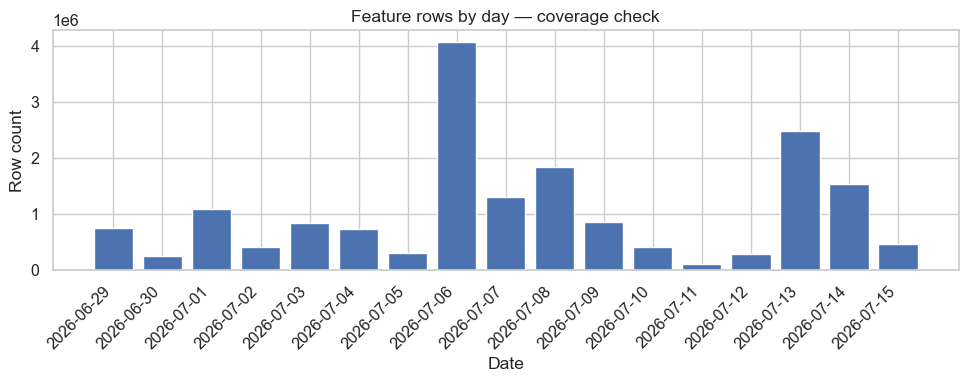

In [9]:
# Cell 8 — Summary: row count, date range, null %, row count by day
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 100

print('=' * 70)
print('SUMMARY — v0 feature snapshot')
print('=' * 70)
print(f'Row count       : {len(output_df):,}')
print(f'Columns         : {output_df.shape[1]}')
print(f'Date range      : {output_df["source_date"].min()} -> {output_df["source_date"].max()}')
print()
print('Null % per column:')
null_pct = (output_df.isnull().mean() * 100).round(2)
print(null_pct.to_string())

counts_by_day = output_df['source_date'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(counts_by_day.index, counts_by_day.values, color='#4C72B0')
ax.set_title('Feature rows by day — coverage check')
ax.set_xlabel('Date')
ax.set_ylabel('Row count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()